In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from src.datasets.mos2_sef_surrogate import ExpertSurrogateDataset, EXPERT_FEATURES

class SAPExpertHead(nn.Module):
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.linear_1 = nn.Linear(128 * 128, 128 * 128)
        self.linear_2 = nn.Linear(128 * 128, 1)
        
    def forward(self, x):
        x = self.linear_1(x)
        x = torch.relu(x)
        x = self.linear_2(x)
        return x

In [2]:
STEPS = 1000
expert_features = EXPERT_FEATURES[0: 1]

dataset = ExpertSurrogateDataset(
    steps_per_epoch=STEPS, 
    expert_features=expert_features
)
dataloader = DataLoader(dataset)

for item in dataloader:
    target: torch.Tensor = item['target'].cuda()
    y:      torch.Tensor = item['y'].cuda().flatten()
    print(y.shape, target.shape)
    break

torch.Size([16384]) torch.Size([1, 1])


In [3]:
model = SAPExpertHead().cuda()

In [4]:
import tqdm

optim = torch.optim.Adam(model.parameters())
losses = []

for item in tqdm.tqdm(dataloader):

    target: torch.Tensor = item['target'].cuda()
    y:      torch.Tensor = item['y'].cuda().flatten()
    y_hat:  torch.Tensor = model(y)

    loss = torch.nn.functional.l1_loss(y_hat, target)
    
    optim.zero_grad()
    loss.backward()
    optim.step()

    losses.append(loss.item())

  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_3320547/246036762.py:12: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = torch.nn.functional.l1_loss(y_hat, target)
100%|██████████| 1000/1000 [07:21<00:00,  2.27it/s]


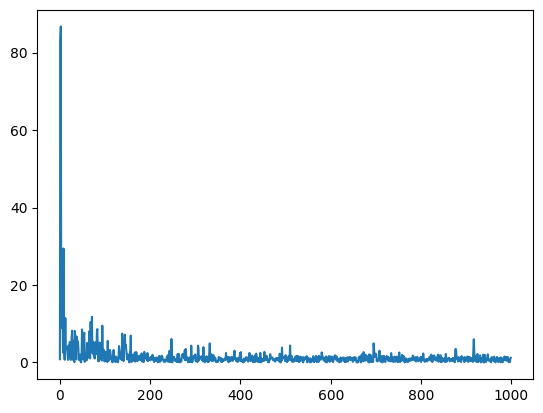

In [6]:
import matplotlib.pyplot as plt

plt.plot(losses);